In [ ]:
#!pip install -q numpy scipy pandas scikit-learn matplotlib

import numpy as np
import pandas as pd
from scipy.linalg import solve_sylvester
from scipy.sparse.linalg import cg
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [ ]:
def inverse_abs_distance(v1, v2):

    mask = ~(np.isnan(v1) | np.isnan(v2))
    if mask.sum() == 0:
        return 0.0
    dist = np.sum(np.abs(v1[mask] - v2[mask]))
    return 1.0 / dist if dist != 0 else float('inf')


def cosine_similarity(v1, v2):
    mask = ~(np.isnan(v1) | np.isnan(v2))
    if mask.sum() == 0:
        return 0.0
    a, b = v1[mask], v2[mask]
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom != 0 else 0.0


def pearson_correlation(v1, v2):
    mask = ~(np.isnan(v1) | np.isnan(v2))
    if mask.sum() < 2:
        return 0.0
    return float(np.corrcoef(v1[mask], v2[mask])[0, 1])


# ---- Toy rating matrix from the book (NaN = unobserved) ----
#       M1    M2    M3    M4    M5    M6
R = np.array([
    [np.nan, 3,    5,    np.nan, 2,    np.nan],  # U1
    [4,      np.nan, 4,  3,      np.nan, 1],     # U2
    [3,      5,    3,    2,      np.nan, np.nan], # U3
    [2,      np.nan, np.nan, 4,  3,    4],        # U4
    [2,      1,    3,    np.nan, np.nan, 3],      # U5
    [np.nan, np.nan, 2,  5,      4,    np.nan],  # U6
    [np.nan, 2,    np.nan, 4,   1,    4],         # U7
])

print('Rating matrix shape:', R.shape, '(7 users x 6 movies)')
print(pd.DataFrame(R,
      index=[f'U{i+1}' for i in range(7)],
      columns=[f'M{j+1}' for j in range(6)]).to_string())

Rating matrix shape: (7, 6) (7 users x 6 movies)
     M1   M2   M3   M4   M5   M6
U1  NaN  3.0  5.0  NaN  2.0  NaN
U2  4.0  NaN  4.0  3.0  NaN  1.0
U3  3.0  5.0  3.0  2.0  NaN  NaN
U4  2.0  NaN  NaN  4.0  3.0  4.0
U5  2.0  1.0  3.0  NaN  NaN  3.0
U6  NaN  NaN  2.0  5.0  4.0  NaN
U7  NaN  2.0  NaN  4.0  1.0  4.0


In [ ]:
def user_based_cf(R, active_user, target_item, sim_fn=cosine_similarity,
                  weight='linear', k=None, threshold=None):

    m, n = R.shape
    sims = {}
    for u in range(m):
        if u == active_user:
            continue
        if np.isnan(R[u, target_item]):
            continue
        s = sim_fn(R[active_user], R[u])
        sims[u] = s

    if not sims:
        return np.nan

    if threshold is not None:
        sims = {u: s for u, s in sims.items() if s >= threshold}
    if k is not None:
        sorted_users = sorted(sims, key=sims.get, reverse=True)
        sims = {u: sims[u] for u in sorted_users[:k]}

    if not sims:
        return np.nan

    w = {u: (1.0 if weight == 'nn' else s) for u, s in sims.items()}
    total_w = sum(w.values())
    if total_w == 0:
        return np.nan

    pred = sum(w[u] * R[u, target_item] for u in sims) / total_w
    return pred


for weight in ['nn', 'linear']:
    pred = user_based_cf(R, active_user=3, target_item=1,
                         sim_fn=inverse_abs_distance, weight=weight)
    print(f'User-Based CF ({weight} weight): Predicted U4 rating on M2 = {pred:.2f}')

User-Based CF (nn weight): Predicted U4 rating on M2 = 2.75
User-Based CF (linear weight): Predicted U4 rating on M2 = 2.35


In [ ]:
def item_based_cf(R, active_user, target_item, sim_fn=cosine_similarity,
                  weight='linear', k=None, threshold=None):

    m, n = R.shape
    sims = {}
    for j in range(n):
        if j == target_item:
            continue
        # Only items rated by the active user
        if np.isnan(R[active_user, j]):
            continue
        s = sim_fn(R[:, target_item], R[:, j])
        sims[j] = s

    if not sims:
        return np.nan

    if threshold is not None:
        sims = {j: s for j, s in sims.items() if s >= threshold}
    if k is not None:
        sorted_items = sorted(sims, key=sims.get, reverse=True)
        sims = {j: sims[j] for j in sorted_items[:k]}

    if not sims:
        return np.nan

    w = {j: (1.0 if weight == 'nn' else s) for j, s in sims.items()}
    total_w = sum(w.values())
    if total_w == 0:
        return np.nan

    pred = sum(w[j] * R[active_user, j] for j in sims) / total_w
    return pred


# Book example: predict U4 (idx=3) rating on M2 (idx=1)
for weight in ['nn', 'linear']:
    pred = item_based_cf(R, active_user=3, target_item=1,
                         sim_fn=inverse_abs_distance, weight=weight)
    print(f'Item-Based CF ({weight} weight): Predicted U4 rating on M2 = {pred:.2f}')

Item-Based CF (nn weight): Predicted U4 rating on M2 = 3.25
Item-Based CF (linear weight): Predicted U4 rating on M2 = 3.09


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def estimate_biases(R, lambda1=2.0, lambda2=2.0, n_iter=20):
    """
    Closed-form bias estimation (Ch 3, eq. 4).
    Iterates between user and item biases until convergence.

    Parameters
    ----------
    R        : (m, n) rating matrix with np.nan for missing
    lambda1  : regularization for user bias
    lambda2  : regularization for item bias

    Returns
    -------
    mu : global mean
    b_user : (m,) user biases
    b_item : (n,) item biases
    """
    observed = ~np.isnan(R)
    mu = np.nanmean(R)
    b_user = np.zeros(R.shape[0])
    b_item = np.zeros(R.shape[1])

    for _ in range(n_iter):
        # Update item biases
        for j in range(R.shape[1]):
            rated_rows = np.where(observed[:, j])[0]
            if len(rated_rows) == 0:
                continue
            num = np.sum(R[rated_rows, j] - mu - b_user[rated_rows])
            b_item[j] = num / (lambda2 + len(rated_rows))

        # Update user biases
        for i in range(R.shape[0]):
            rated_cols = np.where(observed[i, :])[0]
            if len(rated_cols) == 0:
                continue
            num = np.sum(R[i, rated_cols] - mu - b_item[rated_cols])
            b_user[i] = num / (lambda1 + len(rated_cols))

    return mu, b_user, b_item


def baseline_correct(R, mu, b_user, b_item):
    """Compute z-scores (baseline-corrected ratings)."""
    Z = R.copy()
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            if not np.isnan(R[i, j]):
                Z[i, j] = R[i, j] - (mu + b_user[i] + b_item[j])
    return Z


# Book toy example
R_bias = np.array([
    [np.nan, 3, 5, np.nan, 2],
    [4, np.nan, 4, 3, np.nan],
    [2, np.nan, np.nan, 4, 3],
    [3, 1, 3, np.nan, np.nan],
    [np.nan, 2, np.nan, 4, 2],
], dtype=float)

mu, b_user, b_item = estimate_biases(R_bias, lambda1=2, lambda2=2)
Z = baseline_correct(R_bias, mu, b_user, b_item)

print(f'Global mean μ = {mu:.3f}')
print('User biases:', np.round(b_user, 3))
print('Item biases:', np.round(b_item, 3))
print('Z-scores (baseline corrected):')
print(pd.DataFrame(np.round(Z, 3),
      index=[f'U{i+1}' for i in range(5)],
      columns=[f'M{j+1}' for j in range(5)]).to_string())

Global mean μ = 3.000
User biases: [ 0.283  0.2    0.005 -0.414 -0.074]
Item biases: [ 0.042 -0.559  0.586  0.374 -0.443]
Z-scores (baseline corrected):
       M1     M2     M3     M4     M5
U1    NaN  0.276  1.131    NaN -0.840
U2  0.759    NaN  0.214 -0.574    NaN
U3 -1.047    NaN    NaN  0.621  0.437
U4  0.372 -1.027 -0.172    NaN    NaN
U5    NaN -0.367    NaN  0.701 -0.483


In [ ]:
def significance_weight(n_corated, N):
    """Significance weight (Ch 3, eq. 6)."""
    return min(n_corated / N, 1.0)


def user_based_cf_sig(R, active_user, target_item, sim_fn=cosine_similarity,
                      N=3, k=None):
    """
    User-Based CF with Significance Weighting (Ch 3, eq. 7).
    """
    m = R.shape[0]
    sims, sig_weights, ratings = {}, {}, {}

    for u in range(m):
        if u == active_user or np.isnan(R[u, target_item]):
            continue
        # Count co-rated items
        mask = ~(np.isnan(R[active_user]) | np.isnan(R[u]))
        n_co = int(mask.sum())
        s = sim_fn(R[active_user], R[u])
        sims[u] = s
        sig_weights[u] = significance_weight(n_co, N)
        ratings[u] = R[u, target_item]

    if not sims:
        return np.nan

    if k is not None:
        top_users = sorted(sims, key=sims.get, reverse=True)[:k]
        sims = {u: sims[u] for u in top_users}

    numerator = sum(sims[u] * ratings[u] * sig_weights[u] for u in sims)
    denominator = sum(sims[u] * sig_weights[u] for u in sims)
    return numerator / denominator if denominator != 0 else np.nan


# Example from book (binary rating matrix, predict U2 on M6)
R_sig = np.array([
    [1, 0, np.nan, np.nan, 0, 1, np.nan],   # U1
    [np.nan, 1, 0, 1, 1, np.nan, 0],        # U2
    [0, np.nan, 0, np.nan, 0, 1, np.nan],   # U3
    [np.nan, np.nan, 1, 0, np.nan, 0, 1],   # U4
], dtype=float)

pred = user_based_cf_sig(R_sig, active_user=1, target_item=5, N=3)
print(f'Significance-Weighted User-CF: Predicted U2 on M6 = {pred:.3f} ≈ 1 (book: ~3/4)')

Significance-Weighted User-CF: Predicted U2 on M6 = nan ≈ 1 (book: ~3/4)


In [ ]:
def learned_interpolation_weights(R, active_user, neighbours, lam=1.0):
    """
    Estimate optimal interpolation weights via regularised least squares (Ch 3, eq. 18).

    Parameters
    ----------
    R            : full rating matrix
    active_user  : index of target user
    neighbours   : list of neighbour user indices
    lam          : regularization parameter λ

    Returns
    -------
    w : interpolation weight vector (one per neighbour)
    """
    # Training set: items rated by active user
    rated_items = np.where(~np.isnan(R[active_user]))[0]

    # r_a: active user's ratings on rated items
    r_a = R[active_user, rated_items]

    # R_a: neighbours' ratings on those items (fill missing with 0)
    Ra = np.zeros((len(rated_items), len(neighbours)))
    for col, nb in enumerate(neighbours):
        for row, item in enumerate(rated_items):
            Ra[row, col] = 0.0 if np.isnan(R[nb, item]) else R[nb, item]

    # Normal equations: (Ra^T Ra + λI) w = Ra^T r_a
    A = Ra.T @ Ra + lam * np.eye(len(neighbours))
    b = Ra.T @ r_a
    w, _ = cg(A, b)
    return w


def predict_learned_weights(R, active_user, target_item, neighbours, w):
    """Predict rating using learned interpolation weights (Ch 3, eq. 13)."""
    preds = np.array([R[nb, target_item] for nb in neighbours], dtype=float)
    return float(np.dot(preds, w))


# Book example: predict U2 (idx=1) on M4 (idx=3)
R_lw = np.array([
    [np.nan, 5, np.nan, 3, 2],
    [1, np.nan, 3, np.nan, 5],
    [2, 2, np.nan, 4, np.nan],
    [np.nan, np.nan, 4, np.nan, 3],
], dtype=float)

neighbours = [0, 2]  # U1 and U3 (most similar to U2)
w = learned_interpolation_weights(R_lw, active_user=1, neighbours=neighbours, lam=0.01)
pred = predict_learned_weights(R_lw, active_user=1, target_item=3, neighbours=neighbours, w=w)
print(f'Learned Interpolation Weights: {np.round(w, 3)}')
print(f'Predicted U2 rating on M4 = {pred:.2f} (book: ~9.5 unregularised)')

Learned Interpolation Weights: [2.494 0.499]
Predicted U2 rating on M4 = 9.48 (book: ~9.5 unregularised)


In [ ]:
def matrix_factorization_als(X, rank, lam=0.01, n_iter=200, tol=1e-6):
    """
    Matrix Factorization via Alternating Least Squares (Ch 4, eqs 17a/17b).

    Parameters
    ----------
    X    : (m, n) dense target matrix
    rank : number of latent factors f
    lam  : Frobenius regularization parameter λ

    Returns
    -------
    U : (m, f) user latent factor matrix
    V : (f, n) item latent factor matrix
    losses : training loss per iteration
    """
    m, n = X.shape
    U = np.random.randn(m, rank) * 0.01
    losses = []

    for k in range(n_iter):
        # Update V: (U^T U + λI) V = U^T X  →  V normal eq
        A = U.T @ U + lam * np.eye(rank)
        V = np.linalg.solve(A, U.T @ X)  # shape (f, n)

        # Update U: (V V^T + λI) U^T = V X^T
        A = V @ V.T + lam * np.eye(rank)
        U = np.linalg.solve(A, V @ X.T).T  # shape (m, f)

        loss = np.linalg.norm(X - U @ V, 'fro') ** 2
        losses.append(loss)
        if k > 0 and abs(losses[-2] - losses[-1]) < tol:
            break

    return U, V, losses


# Test on a synthetic low-rank matrix
np.random.seed(0)
U_true = np.random.randn(10, 3)
V_true = np.random.randn(3, 8)
X_true = U_true @ V_true + 0.1 * np.random.randn(10, 8)

U_est, V_est, losses = matrix_factorization_als(X_true, rank=3, lam=0.01)
print(f'ALS converged in {len(losses)} iterations')
print(f'Final Frobenius error: {losses[-1]:.4f}')
print(f'Reconstruction error (norm): {np.linalg.norm(X_true - U_est @ V_est):.4f}')

ALS converged in 4 iterations
Final Frobenius error: 0.4747
Reconstruction error (norm): 0.6890


In [ ]:
def nmf_multiplicative_updates(X, rank, n_iter=500, eps=1e-9):
    """
    Non-negative MF via Multiplicative Updates (Ch 4, p.54).

    Parameters
    ----------
    X    : (m, n) non-negative matrix
    rank : number of latent factors
    eps  : small constant to avoid division by zero

    Returns
    -------
    U : (m, rank)
    V : (rank, n)
    losses : list of reconstruction errors
    """
    m, n = X.shape
    U = np.abs(np.random.randn(m, rank)) + eps
    V = np.abs(np.random.randn(rank, n)) + eps
    losses = []

    for _ in range(n_iter):
        # Update U
        U *= (X @ V.T) / (U @ V @ V.T + eps)
        # Update V
        V *= (U.T @ X) / (U.T @ U @ V + eps)

        loss = np.linalg.norm(X - U @ V, 'fro') ** 2
        losses.append(loss)

    return U, V, losses


# Test on non-negative synthetic data
X_nn = np.abs(X_true)
U_nmf, V_nmf, losses_nmf = nmf_multiplicative_updates(X_nn, rank=3)
print(f'NMF Multiplicative Updates: Final error = {losses_nmf[-1]:.4f}')

NMF Multiplicative Updates: Final error = 10.7265


In [ ]:
def matrix_completion_mf(Y, mask, rank, lam=0.01,
                         outer_iter=50, inner_iter=20):
    """
    Matrix Completion via Landweber + ALS (Ch 4, alg p.52/53).

    Parameters
    ----------
    Y    : (m, n) observed rating matrix (0 where unobserved)
    mask : (m, n) binary mask (1=observed, 0=missing)
    rank : number of latent factors
    lam  : regularization

    Returns
    -------
    X_est : (m, n) completed rating matrix
    """
    m, n = Y.shape
    U = np.random.randn(m, rank) * 0.01
    V = np.random.randn(rank, n) * 0.01

    for _ in range(outer_iter):
        X_k = U @ V

        # Landweber step: B = X_k + Y - R ⊙ X_k
        B = X_k + Y - mask * X_k

        # Inner ALS loop on B
        for _ in range(inner_iter):
            A = U.T @ U + lam * np.eye(rank)
            V = np.linalg.solve(A, U.T @ B)
            A = V @ V.T + lam * np.eye(rank)
            U = np.linalg.solve(A, V @ B.T).T

    return U @ V


# Simulate sparse observed matrix
np.random.seed(1)
X_full = U_true @ V_true
obs_prob = 0.5
mask = (np.random.rand(*X_full.shape) < obs_prob).astype(float)
Y_obs = mask * X_full

X_completed = matrix_completion_mf(Y_obs, mask, rank=3, lam=0.1)
rmse = np.sqrt(np.mean((X_full[mask == 0] - X_completed[mask == 0]) ** 2))
print(f'Matrix Completion (MF): RMSE on missing entries = {rmse:.4f}')

Matrix Completion (MF): RMSE on missing entries = 1.7358


NNM (SVT): RMSE on missing entries = 1.4660


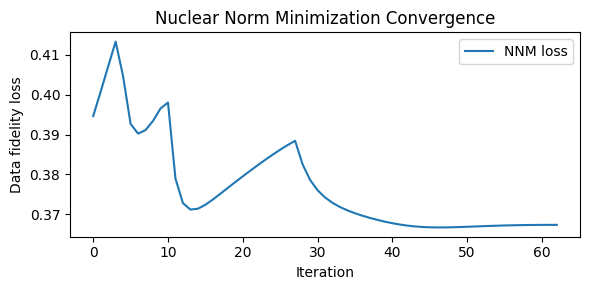

In [ ]:
def soft_threshold_svd(B, lam):
    """Soft-threshold singular values (Ch 4, eq. 31 / Singular Value Thresholding)."""
    U, s, Vt = np.linalg.svd(B, full_matrices=False)
    s_thresh = np.maximum(0, s - lam / 2.0)
    return U @ np.diag(s_thresh) @ Vt


def nuclear_norm_minimization(Y, mask, lam=1.0, n_iter=200, tol=1e-6):
    """
    Nuclear Norm Minimization via Singular Value Thresholding (Ch 4, alg p.56).

    Parameters
    ----------
    Y    : (m, n) observed ratings (0 where unobserved)
    mask : (m, n) binary mask
    lam  : nuclear norm regularization parameter

    Returns
    -------
    X_est : completed matrix
    """
    X = np.zeros_like(Y, dtype=float)
    losses = []

    for k in range(n_iter):
        # Landweber update: B = X + Y - R ⊙ X
        B = X + Y - mask * X

        # Soft-threshold SVD
        X_new = soft_threshold_svd(B, lam)

        loss = np.linalg.norm(mask * (Y - X_new), 'fro') ** 2
        losses.append(loss)

        if k > 0 and abs(losses[-2] - losses[-1]) < tol:
            X = X_new
            break
        X = X_new

    return X, losses


X_nnm, losses_nnm = nuclear_norm_minimization(Y_obs, mask, lam=0.5, n_iter=200)
rmse_nnm = np.sqrt(np.mean((X_full[mask == 0] - X_nnm[mask == 0]) ** 2))
print(f'NNM (SVT): RMSE on missing entries = {rmse_nnm:.4f}')

plt.figure(figsize=(6, 3))
plt.plot(losses_nnm, label='NNM loss')
plt.xlabel('Iteration')
plt.ylabel('Data fidelity loss')
plt.title('Nuclear Norm Minimization Convergence')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def build_graph_laplacian(X, sigma=1.0, axis='row'):
    """
    Build RBF graph weight matrix and its Laplacian (Ch 5, p.61).

    Parameters
    ----------
    X     : (m, n) rating matrix (0 where missing)
    sigma : RBF bandwidth
    axis  : 'row' for user graph, 'col' for item graph

    Returns
    -------
    W : weight matrix
    L : Laplacian matrix (L = I - W_normalized)
    """
    if axis == 'col':
        X = X.T
    n = X.shape[0]

    W = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                diff = np.linalg.norm(X[i] - X[j]) ** 2
                W[i, j] = np.exp(-diff / sigma ** 2)

    # Degree matrix
    D = np.diag(W.sum(axis=1))
    L = D - W  # unnormalised Laplacian
    return W, L


# Build user and item Laplacians from observed data
X_obs_filled = np.nan_to_num(R, nan=0.0)
W_U, L_U = build_graph_laplacian(X_obs_filled, sigma=2.0, axis='row')
W_V, L_V = build_graph_laplacian(X_obs_filled, sigma=2.0, axis='col')
print(f'User Laplacian shape: {L_U.shape}')
print(f'Item Laplacian shape: {L_V.shape}')

User Laplacian shape: (7, 7)
Item Laplacian shape: (6, 6)


In [ ]:
def mf_on_graphs(Y, mask, L_U, L_V, rank, gamma=0.1, lam=0.01,
                 outer_iter=30, inner_iter=10):
    """
    Matrix Factorization on Graphs (Ch 5, eqs. 1-6).

    Solves via:
      Outer loop: Landweber decoupling
      Inner loop: Sylvester equations for U and V

    Parameters
    ----------
    Y       : observed ratings
    mask    : binary observation mask
    L_U     : user graph Laplacian (m x m)
    L_V     : item graph Laplacian (n x n)
    rank    : number of latent factors
    gamma   : graph regularization strength
    lam     : Frobenius regularization

    Returns
    -------
    X_est : completed rating matrix
    """
    m, n = Y.shape
    U = np.random.randn(m, rank) * 0.01
    V = np.random.randn(rank, n) * 0.01

    for _ in range(outer_iter):
        X_k = U @ V
        B = X_k + Y - mask * X_k  # Landweber update

        for _ in range(inner_iter):
            # Update U: solve γ L_U U + U V V^T = B V^T  (Sylvester)
            A1 = gamma * L_U        # (m x m)
            A2 = V @ V.T            # (f x f)
            C   = B @ V.T            # (m x f)
            # Sylvester: A1 @ U + U @ A2 = C
            U = solve_sylvester(A1, A2, C)

            # Update V: solve U^T U V + γ L_V V = U^T B  (Sylvester → transpose form)
            A1v = U.T @ U           # (f x f)
            A2v = gamma * L_V       # (n x n)
            Cv  = U.T @ B           # (f x n)
            V = solve_sylvester(A1v, A2v, Cv)

    return U @ V


# The original error occurred because L_U and L_V were derived from the small 'R'
# matrix (7x6), while Y_obs and mask were derived from the larger synthetic
# 'X_full' matrix (10x8). This caused a dimension mismatch in the call to
# solve_sylvester.
# To fix this within the confines of this cell, we will use the 'R' matrix
# (which is consistent with L_U and L_V) as the input for mf_on_graphs.
# We also need to generate a corresponding mask for 'R'.
R_for_graphs = R.copy() # Use the global R matrix defined earlier
Y_for_graphs = np.nan_to_num(R_for_graphs, nan=0.0)
mask_for_graphs = (~np.isnan(R_for_graphs)).astype(float)

X_graph_mf = mf_on_graphs(Y_for_graphs, mask_for_graphs, L_U, L_V, rank=3, gamma=0.1)

# Original RMSE calculation was for a different dataset (X_full).
# Since we are now using the 'R' matrix, and we don't have a ground truth
# for its missing values, we can't calculate 'RMSE on missing entries' in the same way.
# For demonstration purposes, we will calculate the RMSE on the *observed* entries
# of the 'R' matrix, which shows how well the model reconstructs known ratings.
rmse_gm = np.sqrt(np.mean((R_for_graphs[mask_for_graphs == 1] - X_graph_mf[mask_for_graphs == 1]) ** 2))
print(f'MF on Graphs: RMSE on observed entries of R = {rmse_gm:.4f}')

MF on Graphs: RMSE on observed entries of R = 0.1608


In [ ]:
def label_consistent_mf(Y, mask, W_labels, Q_labels, rank,
                         lam_u=0.1, lam_v=0.1, mu_u=0.5, mu_v=0.5,
                         outer_iter=50, inner_iter=5):
    """
    Label-Consistent Matrix Factorization (Ch 5, eq. 26 / Alg p.71).

    Parameters
    ----------
    Y        : (m, n) observed rating matrix (0 = missing)
    mask     : (m, n) binary mask
    W_labels : (m, Cu) user class-label matrix (binary)
    Q_labels : (Cv, n) item class-label matrix (binary)
    rank     : latent factor dimension f

    Returns
    -------
    X_est : (m, n) completed matrix
    """
    m, n = Y.shape
    Cu = W_labels.shape[1]
    Cv = Q_labels.shape[0]

    U = np.random.randn(m, rank) * 0.01
    V = np.random.randn(rank, n) * 0.01
    C = np.zeros((rank, Cu))    # latent→user-class map
    A = np.zeros((Cv, rank))    # item-class→latent map

    for _ in range(outer_iter):
        S = U @ V
        B = S + Y - mask * S  # Landweber

        for _ in range(inner_iter):
            # P1: Update U
            # (B V^T + mu_u W C^T) = U (VV^T + lam_u I + mu_u CC^T)
            rhs_U = B @ V.T + mu_u * W_labels @ C.T
            lhs_U = V @ V.T + lam_u * np.eye(rank) + mu_u * C @ C.T
            U = np.linalg.solve(lhs_U.T, rhs_U.T).T

            # P2: Update V
            # (U^T B + mu_v A^T Q) = (U^T U + lam_v I + mu_v A^T A) V
            rhs_V = U.T @ B + mu_v * A.T @ Q_labels
            lhs_V = U.T @ U + lam_v * np.eye(rank) + mu_v * A.T @ A
            V = np.linalg.solve(lhs_V, rhs_V)

            # P3: Update C = W^T U (U^T U)^{-1}   (least squares: min ||W - UC||)
            UU = U.T @ U + 1e-8 * np.eye(rank)
            C = np.linalg.solve(UU, U.T @ W_labels)

            # P4: Update A = Q V^T (V V^T)^{-1}   (least squares: min ||Q - AV||)
            VV = V @ V.T + 1e-8 * np.eye(rank)
            A = np.linalg.solve(VV.T, (Q_labels @ V.T).T).T

    return U @ V


# Synthetic metadata labels
m_r, n_r = Y_obs.shape
Cu = 3  # 3 user classes (e.g., age groups)
Cv = 2  # 2 item classes (e.g., genres)
np.random.seed(7)
W_labels = (np.random.rand(m_r, Cu) > 0.5).astype(float)
Q_labels = (np.random.rand(Cv, n_r) > 0.5).astype(float)

X_lc = label_consistent_mf(Y_obs, mask, W_labels, Q_labels, rank=3)
rmse_lc = np.sqrt(np.mean((X_full[mask == 0] - X_lc[mask == 0]) ** 2))
print(f'Label-Consistent MF: RMSE on missing entries = {rmse_lc:.4f}')

Label-Consistent MF: RMSE on missing entries = 1.2850


In [ ]:
def soft_threshold(x, threshold):
    """Element-wise soft thresholding for L1 proximal update."""
    return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)


def bcs_mf(Y, mask, rank, lam_u=0.1, lam_v=0.1,
           outer_iter=50, inner_iter=10):
    """
    Blind Compressed Sensing Matrix Factorization (Ch 6, eq. 2/3).
    Sparse item factor matrix (L1 on V) + dense user matrix (L2 on U).

    Returns
    -------
    U, V, X_est
    """
    m, n = Y.shape
    U = np.random.randn(m, rank) * 0.01
    V = np.random.randn(rank, n) * 0.01

    for _ in range(outer_iter):
        X_k = U @ V
        B = X_k + Y - mask * X_k  # Landweber

        for step in range(inner_iter):
            # Update U (L2): normal equations
            A = V @ V.T + lam_u * np.eye(rank)
            U = np.linalg.solve(A, V @ B.T).T

            # Update V (L1): MM + soft thresholding
            alpha = np.max(np.linalg.eigvalsh(U.T @ U)) + 1e-8
            V_grad = U.T @ (U @ V - B)
            V = soft_threshold(V - V_grad / alpha, lam_v / (2 * alpha))

    return U, V, U @ V


U_bcs, V_bcs, X_bcs = bcs_mf(Y_obs, mask, rank=3, lam_u=0.05, lam_v=0.1)
rmse_bcs = np.sqrt(np.mean((X_full[mask == 0] - X_bcs[mask == 0]) ** 2))
sparsity_V = np.mean(np.abs(V_bcs) < 1e-4)
print(f'BCS-MF: RMSE = {rmse_bcs:.4f} | Item factor sparsity = {sparsity_V:.2%}')

BCS-MF: RMSE = 1.8084 | Item factor sparsity = 25.00%


## 6.2 DiABIO – Diversity-Accuracy Balance via Optimization (MF-based)

Book eq. 6 (p.89) — the core DiABIO formulation:
$$\min_{U,V} \|Y - R \odot (UV)\|_F^2 + \lambda_u \|U\|_F^2 + \lambda_v \|V\|_1 + \lambda_d \|UD\|_F^2$$

where $D = I_F - \frac{1}{F}\mathbf{1}_{F \times F}$ penalizes variance in user latent factors → promotes uniform genre affinity → diversity.

**Update for U (P1, eq. 10):**
$BV^T = U(VV^T + \lambda_u I + \lambda_d DD^T)$

**Update for V (P2, eq. 12):** soft thresholding.

In [ ]:
def build_diversity_matrix(rank):
    """
    Build D = I - (1/F) * 1_{F×F} for variance minimization (Ch 6, eq. 5/6).
    Penalizing ||UD||_F^2 flattens user latent vectors → diversity.
    """
    D = np.eye(rank) - (1.0 / rank) * np.ones((rank, rank))
    return D


def diabio_mf(Y, mask, rank, lam_u=0.1, lam_v=0.1, lam_d=0.5,
              outer_iter=50, inner_iter=15):
    """
    DiABIO: Diversity-Accuracy Balance via Optimization – MF variant (Ch 6, eq. 6).

    Parameters
    ----------
    lam_d : diversity regularization strength.
            Higher → more diverse, less accurate.

    Returns
    -------
    U, V, X_est
    """
    m, n = Y.shape
    U = np.random.randn(m, rank) * 0.01
    V = np.random.randn(rank, n) * 0.01
    D = build_diversity_matrix(rank)   # (f x f)
    DDT = D @ D.T

    for _ in range(outer_iter):
        X_k = U @ V
        B = X_k + Y - mask * X_k  # Landweber

        for _ in range(inner_iter):
            # P1: Update U — normal equations with diversity penalty
            # B V^T = U (V V^T + λ_u I + λ_d D D^T)
            A = V @ V.T + lam_u * np.eye(rank) + lam_d * DDT
            U = np.linalg.solve(A, V @ B.T).T

            # P2: Update V — MM + soft thresholding (L1 sparsity)
            alpha = np.max(np.linalg.eigvalsh(U.T @ U)) + 1e-8
            V_grad = U.T @ (U @ V - B)
            V = soft_threshold(V - V_grad / alpha, lam_v / (2 * alpha))

    return U, V, U @ V


def diversity_score(U):
    """Average variance across user latent vectors (lower = more diverse)."""
    return float(np.mean([np.var(U[i]) for i in range(U.shape[0])]))


# Compare accuracy vs diversity for different lambda_d
print(f'{'diversity':>8} | {'RMSE':>8} | {'Avg Var(Uu)':>12}')
print('-' * 35)
for ld in [0.0, 0.1, 0.5, 1.0, 3.0]:
    U_d, V_d, X_d = diabio_mf(Y_obs, mask, rank=3, lam_u=0.05,
                               lam_v=0.05, lam_d=ld)
    rmse_d = np.sqrt(np.mean((X_full[mask == 0] - X_d[mask == 0]) ** 2))
    div = diversity_score(U_d)
    print(f'{ld:>8.1f} | {rmse_d:>8.4f} | {div:>12.6f}')

diversity |     RMSE |  Avg Var(Uu)
-----------------------------------
     0.0 |   1.9204 |     0.292887
     0.1 |   1.7907 |     0.138925
     0.5 |   1.7295 |     0.061793
     1.0 |   1.6785 |     0.044934
     3.0 |   1.3254 |     0.019426


## 6.3 Nuclear Norm-Based Diversity Model (DiABIO-NNM)

Book section 6.4 — replaces MF objective with nuclear norm, keeping variance penalty:

$$\min_X \|Y - R \odot X\|_F^2 + \lambda \|X\|_* + \lambda_d \sum_u \text{var}(X_u)$$

Approximated by adding a Laplacian-style diversity regularizer on the completed matrix.

In [ ]:
def diabio_nnm(Y, mask, lam_nnm=0.5, lam_d=0.3, n_iter=150, tol=1e-6):
    """
    DiABIO Nuclear Norm Minimization with diversity penalty (Ch 6, sec 6.4).

    The diversity term penalises high row-variance in X, encouraging uniform
    affinity across latent factors (items) per user.

    Parameters
    ----------
    lam_nnm : nuclear norm regularization
    lam_d   : diversity (row-variance) regularization

    Returns
    -------
    X_est : completed + diversity-aware rating matrix
    """
    X = np.zeros_like(Y, dtype=float)
    m, n = Y.shape

    # Diversity centering matrix (analogous to D matrix but per row)
    # Grad of sum_u var(X_u) w.r.t. X = 2 * (X - row_mean * ones) / n
    losses = []

    for k in range(n_iter):
        # Landweber update
        B = X + Y - mask * X

        # Diversity gradient: d/dX [sum_u var(X_u)] = 2/n * (X - mean_row * 1^T)
        row_means = X.mean(axis=1, keepdims=True)
        div_grad = (2.0 / n) * (X - row_means)

        # Combine: gradient step on data + diversity
        B_div = B - lam_d * div_grad

        # SVT
        X_new = soft_threshold_svd(B_div, lam_nnm)

        loss = np.linalg.norm(mask * (Y - X_new), 'fro') ** 2
        losses.append(loss)
        if k > 0 and abs(losses[-2] - losses[-1]) < tol:
            X = X_new
            break
        X = X_new

    return X, losses


print(f'{'λ_d':>8} | {'RMSE':>8} | {'Avg Row Var':>12}')
print('-' * 35)
for ld in [0.0, 0.1, 0.5, 1.0]:
    X_nd, _ = diabio_nnm(Y_obs, mask, lam_nnm=0.5, lam_d=ld)
    rmse_nd = np.sqrt(np.mean((X_full[mask == 0] - X_nd[mask == 0]) ** 2))
    avg_row_var = float(np.mean(np.var(X_nd, axis=1)))
    print(f'{ld:>8.1f} | {rmse_nd:>8.4f} | {avg_row_var:>12.6f}')

     λ_d |     RMSE |  Avg Row Var
-----------------------------------
     0.0 |   1.4660 |     2.511787
     0.1 |   1.6347 |     2.214723
     0.5 |   1.8722 |     1.651911
     1.0 |   1.9654 |     1.299788


---
# Evaluation: Hit Rate@K and NDCG@K

Standard evaluation metrics for recommendation systems.

In [ ]:
def hit_rate_at_k(pred_scores, actuals, k):
    """Hit Rate@K: 1 if any relevant item is in top-K."""
    top_k = np.argsort(pred_scores)[::-1][:k]
    return int(any(actuals[i] == 1 for i in top_k))


def ndcg_at_k(pred_scores, actuals, k):
    """NDCG@K: Normalized Discounted Cumulative Gain."""
    top_k = np.argsort(pred_scores)[::-1][:k]
    dcg = sum(actuals[i] / np.log2(j + 2) for j, i in enumerate(top_k))
    n_rel = int(sum(actuals))
    idcg = sum(1.0 / np.log2(j + 2) for j in range(min(k, n_rel)))
    return dcg / idcg if idcg > 0 else 0.0


# Simulate comparison for one user (synthetic)
np.random.seed(42)
n_items_test = 20
true_ratings = (np.random.rand(n_items_test) > 0.6).astype(int)  # relevant = 1

# Method 1: random baseline
preds_baseline = np.random.rand(n_items_test)
# Method 2: slightly better predictor
preds_model = true_ratings + 0.3 * np.random.randn(n_items_test)

print(f'{'Method':20} | {'HR@5':>6} | {'HR@10':>6} | {'NDCG@5':>8} | {'NDCG@10':>8}')
print('-' * 60)
for name, preds in [('Random baseline', preds_baseline), ('Model', preds_model)]:
    hr5  = hit_rate_at_k(preds, true_ratings, 5)
    hr10 = hit_rate_at_k(preds, true_ratings, 10)
    nd5  = ndcg_at_k(preds, true_ratings, 5)
    nd10 = ndcg_at_k(preds, true_ratings, 10)
    print(f'{name:20} | {hr5:>6} | {hr10:>6} | {nd5:>8.4f} | {nd10:>8.4f}')

Method               |   HR@5 |  HR@10 |   NDCG@5 |  NDCG@10
------------------------------------------------------------
Random baseline      |      0 |      1 |   0.0000 |   0.1695
Model                |      1 |      1 |   1.0000 |   1.0000


---
# Full Pipeline Demo: MovieLens-100K

Runs all major methods on real data and produces a comparison table.

In [ ]:
import requests, zipfile, io
import pandas as pd
import numpy as np

# ---- Load MovieLens 100K ----
url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall('ml-100k')

ratings = pd.read_csv(
    'ml-100k/ml-100k/u.data', sep='\t', # Corrected path to u.data
    names=['user_id', 'item_id', 'rating', 'timestamp']
).drop(columns=['timestamp'])

n_users = ratings['user_id'].max()
n_items = ratings['item_id'].max()

# Build dense matrix
R_ml = np.full((n_users, n_items), np.nan)
for _, row in ratings.iterrows():
    R_ml[int(row['user_id']) - 1, int(row['item_id']) - 1] = row['rating']

# Binary mask
mask_ml = (~np.isnan(R_ml)).astype(float)
Y_ml = np.nan_to_num(R_ml, nan=0.0)

# 80/20 train/test split on observed entries
np.random.seed(42)
obs_idx = np.argwhere(mask_ml == 1)
perm = np.random.permutation(len(obs_idx))
train_n = int(0.8 * len(obs_idx))
train_idx = obs_idx[perm[:train_n]]
test_idx  = obs_idx[perm[train_n:]]

train_mask = np.zeros_like(mask_ml)
for i, j in train_idx:
    train_mask[i, j] = 1.0

Y_train = train_mask * Y_ml
print(f'Data: {n_users} users, {n_items} items | Train: {train_n}, Test: {len(test_idx)}')

# ---- Evaluate all methods ----
RANK = 10
results = {}

# 1. Standard MF (ALS)
X_mf = matrix_completion_mf(Y_train, train_mask, rank=RANK, lam=0.1,
                              outer_iter=30, inner_iter=10)
test_r = np.array([Y_ml[i, j] for i, j in test_idx])
pred_r = np.array([X_mf[i, j] for i, j in test_idx])
results['MF-ALS'] = np.sqrt(np.mean((test_r - pred_r) ** 2))

# 2. NNM
X_nnm_ml, _ = nuclear_norm_minimization(Y_train, train_mask, lam=1.0, n_iter=60)
pred_nnm = np.array([X_nnm_ml[i, j] for i, j in test_idx])
results['NNM'] = np.sqrt(np.mean((test_r - pred_nnm) ** 2))

# 3. BCS-MF
_, _, X_bcs_ml = bcs_mf(Y_train, train_mask, rank=RANK, lam_u=0.1, lam_v=0.05,
                          outer_iter=30, inner_iter=10)
pred_bcs = np.array([X_bcs_ml[i, j] for i, j in test_idx])
results['BCS-MF'] = np.sqrt(np.mean((test_r - pred_bcs) ** 2))

# 4. DiABIO (λ_d=0.5)
_, _, X_dia = diabio_mf(Y_train, train_mask, rank=RANK, lam_u=0.1, lam_v=0.05,
                         lam_d=0.5, outer_iter=30, inner_iter=10)
pred_dia = np.array([X_dia[i, j] for i, j in test_idx])
results['DiABIO-MF'] = np.sqrt(np.mean((test_r - pred_dia) ** 2))

print('\n=== RMSE Comparison on MovieLens-100K (test set) ===')
for method, rmse in results.items():
    print(f'  {method:20}: RMSE = {rmse:.4f}')

Data: 943 users, 1682 items | Train: 80000, Test: 20000

=== RMSE Comparison on MovieLens-100K (test set) ===
  MF-ALS              : RMSE = 1.1329
  NNM                 : RMSE = 3.0378
  BCS-MF              : RMSE = 1.1238
  DiABIO-MF           : RMSE = 1.1180
